# LiDAR In-Mask Filtering Exploration

Standalone notebook to investigate and validate HDBSCAN-based filtering of in-mask LiDAR points.

**Purpose:** Before integrating LiDAR into the main autolabeling pipeline, validate that HDBSCAN correctly isolates the object surface points from background bleeds (walls, ground, adjacent objects) for each SAM3 mask individually.

**Workflow:**
1. Load frame + run SAM3 (or load from cache — avoids re-running SAM3 every time)
2. Load the matching LiDAR sweep (timestamp-synced to the camera frame)
3. Project LiDAR into camera frame
4. Select one SAM3 mask via `MASK_PROMPT` + `MASK_IDX`
5. Keep only in-mask LiDAR points
6. Run HDBSCAN on the 3D points
7. Visualise clusters in BEV and overlaid on the image

## 0. Imports

In [79]:
import sys
import os
import shutil
import tempfile
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import torch
from PIL import Image
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
import hdbscan
import plotly.graph_objects as go

## 1. Config

Change `DATASET` to switch between **`'nuscenes_mini'`** and **`'ecp'`**.

Change `MASK_PROMPT` and `MASK_IDX` to select which SAM3 mask to inspect.  
Re-run from **Section 5** onwards without re-running SAM3 each time (results are cached to disk).

In [80]:
# ══════════════════════════════════════════════════════════════════════════════
# Dataset selector  →  change this one variable to switch datasets
# ══════════════════════════════════════════════════════════════════════════════
DATASET = 'nuscenes_mini'           # 'ecp'  or  'nuscenes_mini'

if DATASET == 'nuscenes_mini':
    DATA_ROOT    = '/workspace/data/nuScenes_mini'
    NUSCENES_VER = 'v1.0-mini'
    SCENE_IDX    = 1
    FRAME_IDX    = 40
elif DATASET == 'ecp':
    DATA_ROOT    = '/workspace/data/ecp'
    NUSCENES_VER = 'v1.0-trainval'
    SCENE_IDX    = 15
    FRAME_IDX    = 2919
else:
    raise ValueError(f'Unknown DATASET: {DATASET!r}')

CAMERA = 'CAM_FRONT'

# ── SAM3 ──────────────────────────────────────────────────────────────────────
DEV_ROOT   = Path('/workspace')
SAM3_CKPT  = None   # set to None → auto-download via HuggingFace Hub

SAM3_PROMPTS = {
    'pedestrian':           'body',
    'car':                  'objects',
    'bicycle':              'objects',
    'motorcycle':           'objects',
    'bus':                  'objects',
    'truck':                'objects',
    'construction vehicle': 'objects',
    'trailer':              'objects',
}
SAM3_SCORE_THRESH = 0.5
MIN_MASK_PX       = 100

# ── Mask selection (change these to inspect a different object) ───────────────
MASK_PROMPT = 'car'    # must be a key in SAM3_PROMPTS
MASK_IDX    = 4        # index within the detections for that prompt (0 = first)

# ── HDBSCAN — per-class parameters ────────────────────────────────────────────
HDBSCAN_PARAMS = {
    'pedestrian':           dict(min_cluster_size=3, min_samples=1, cluster_eps=0.20),
    'bicycle':              dict(min_cluster_size=3, min_samples=1, cluster_eps=0.20),
    'motorcycle':           dict(min_cluster_size=3, min_samples=1, cluster_eps=0.30),
    'car':                  dict(min_cluster_size=2, min_samples=1, cluster_eps=0.50),
    'truck':                dict(min_cluster_size=5, min_samples=1, cluster_eps=0.60),
    'construction vehicle': dict(min_cluster_size=5, min_samples=1, cluster_eps=0.60),
    'bus':                  dict(min_cluster_size=5, min_samples=1, cluster_eps=0.80),
    'trailer':              dict(min_cluster_size=5, min_samples=1, cluster_eps=0.70),
}

# ── LiDAR aggregation ─────────────────────────────────────────────────────────
USE_AGGREGATION = True
N_BEFORE        = 1     # sweeps before anchor
N_AFTER         = 1     # sweeps after anchor

# ── Ego-body exclusion zone ───────────────────────────────────────────────────
# The LiDAR sensor sees its own roof, windshield, and mounting hardware.
# These returns sit at approximately sensor height (z ≈ 1.5 m in ego frame) and
# form a dense horizontal strip when sweeps are aggregated, because the
# reflection position is fixed to the ego body.
#
# Although one might expect these points to be behind the camera (and thus
# discarded), they appear at x ≈ 1–5 m FORWARD from the sensor (reflections
# off windshield glass appear slightly in front of the sensor mounting point).
# At z ≈ camera height, such a point projects to v ≈ cy — the horizontal
# centerline of the image — and lands squarely inside any vehicle mask that
# covers mid-image height.
#
# Fix: remove elevated returns inside an approximate ego-body bounding box.
# Ground-level returns (z < EGO_BOX_Z_MIN) are preserved so that objects
# parked very close to the ego are not affected.
#
# Tune EGO_BOX_Z_MIN to just below the artefact height seen in the 3-D view
# (Section 5b).  The strip should vanish; real object surface points remain.
USE_EGO_BODY_FILTER = True   # set False to disable and see the raw artefact
EGO_BOX_HALF_X = 4.0   # half-length fore/aft of sensor [m]
EGO_BOX_HALF_Y = 1.5   # half-width left/right of sensor [m]
EGO_BOX_Z_MIN  = 0.5   # lower Z cutoff — keep ground returns below this [m]
EGO_BOX_Z_MAX  = 2.5   # upper Z cutoff — keep very tall objects above this [m]

# ── Max LiDAR range filter ────────────────────────────────────────────────────
# Removes points beyond this BEV distance from ego (metres).
# Set +2 m over the 50 m evaluation limit to cut distant background returns
# that could form spurious HDBSCAN clusters inside near-object masks, while
# preserving all points relevant to evaluation.
MAX_LIDAR_RANGE_M = 52.0

# ── Cache ─────────────────────────────────────────────────────────────────────
CACHE_DIR  = Path('/workspace/cache/sam3')
CACHE_FILE = CACHE_DIR / f'sam3_{DATASET}_s{SCENE_IDX}_f{FRAME_IDX}_{CAMERA}.pkl'

_hp = HDBSCAN_PARAMS[MASK_PROMPT]
print(f'Dataset: {DATASET}')
print(f'Frame  : scene {SCENE_IDX}, frame {FRAME_IDX}, {CAMERA}')
print(f'Mask   : prompt="{MASK_PROMPT}", idx={MASK_IDX}')
print(f'HDBSCAN: min_cluster_size={_hp["min_cluster_size"]}  '
      f'min_samples={_hp["min_samples"]}  cluster_eps={_hp["cluster_eps"]}m')
print(f'LiDAR  : {"aggregated (" + str(N_BEFORE) + "+" + str(N_AFTER) + " sweeps)" if USE_AGGREGATION else "single sweep"}')
print(f'Ego-body filter: {"ON" if USE_EGO_BODY_FILTER else "OFF"}', end='')
if USE_EGO_BODY_FILTER:
    print(f'  (|X|<{EGO_BOX_HALF_X}m, |Y|<{EGO_BOX_HALF_Y}m, Z∈[{EGO_BOX_Z_MIN}, {EGO_BOX_Z_MAX}]m)', end='')
print()
print(f'Max range filter: {MAX_LIDAR_RANGE_M} m (BEV distance from ego)')
print(f'Cache  : {CACHE_FILE}')

Dataset: nuscenes_mini
Frame  : scene 1, frame 40, CAM_FRONT
Mask   : prompt="car", idx=4
HDBSCAN: min_cluster_size=2  min_samples=1  cluster_eps=0.5m
LiDAR  : aggregated (1+1 sweeps)
Ego-body filter: ON  (|X|<4.0m, |Y|<1.5m, Z∈[0.5, 2.5]m)
Max range filter: 52.0 m (BEV distance from ego)
Cache  : /workspace/autolabeling/.sam3_cache/sam3_nuscenes_mini_s1_f40_CAM_FRONT.pkl


## 2. Frame Loading

Image  : /workspace/data/nuScenes_mini/sweeps/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151606862404.jpg
  Size : 1600×900   fx=1252.8  fy=1252.8  cx=826.6  cy=470.0


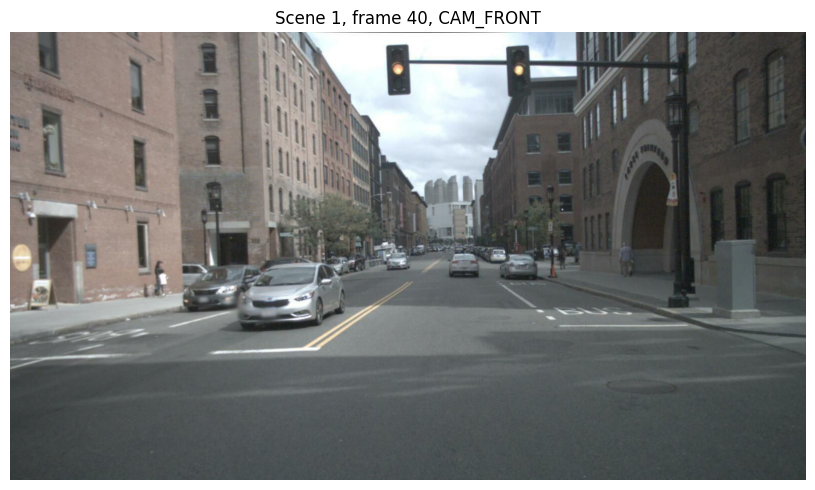

In [81]:
import gc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')

# Add SAM3 repo to path so we can import it in Section 3
sys.path.insert(0, str(DEV_ROOT / 'SAM3'))
os.environ['LIDRA_SKIP_INIT'] = 'true'


def load_frame(nusc, scene_idx, frame_idx, camera='CAM_FRONT'):
    """
    Load image, camera intrinsics, and camera-to-ego extrinsics for one frame.

    Returns
    -------
    img_rgb       : (H, W, 3) uint8 RGB
    img_bgr       : (H, W, 3) uint8 BGR
    K             : (3, 3) float64 intrinsics
    R_c2e         : (3, 3) float64 rotation  camera → ego
    t_c2e         : (3,)   float64 translation camera → ego
    img_path      : str
    cam_sd_token  : str  sample_data token (needed for LiDAR sync)
    """
    scene   = nusc.scene[scene_idx]
    token   = nusc.get('sample', scene['first_sample_token'])['data'][camera]
    for _ in range(frame_idx):
        rec   = nusc.get('sample_data', token)
        token = rec['next']
        assert token, f'frame_idx {frame_idx} exceeds scene length'

    rec      = nusc.get('sample_data', token)
    img_path = nusc.get_sample_data_path(token)
    cal      = nusc.get('calibrated_sensor', rec['calibrated_sensor_token'])

    K     = np.array(cal['camera_intrinsic'], dtype=np.float64)
    R_c2e = Quaternion(cal['rotation']).rotation_matrix.astype(np.float64)
    t_c2e = np.array(cal['translation'], dtype=np.float64)

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb, img_bgr, K, R_c2e, t_c2e, img_path, token


nusc = NuScenes(version=NUSCENES_VER, dataroot=DATA_ROOT, verbose=False)
img_rgb, img_bgr, K, R_c2e, t_c2e, img_path, cam_sd_token = load_frame(
    nusc, SCENE_IDX, FRAME_IDX, CAMERA
)
H, W = img_rgb.shape[:2]
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

# Ego pose at anchor timestamp — needed for multi-sweep motion compensation
cam_sd       = nusc.get('sample_data', cam_sd_token)
cam_ep       = nusc.get('ego_pose', cam_sd['ego_pose_token'])
R_e2g_anchor = Quaternion(cam_ep['rotation']).rotation_matrix.astype(np.float64)
t_e2g_anchor = np.array(cam_ep['translation'], dtype=np.float64)

print(f'Image  : {img_path}')
print(f'  Size : {W}\u00d7{H}   fx={fx:.1f}  fy={fy:.1f}  cx={cx:.1f}  cy={cy:.1f}')

plt.figure(figsize=(14, 5))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f'Scene {SCENE_IDX}, frame {FRAME_IDX}, {CAMERA}')
plt.tight_layout()
plt.show()


## 3. SAM3 Inference (with Cache)

Run SAM3 for every class in `SAM3_PROMPTS` and cache results to disk.
**Re-run this cell once per unique `(SCENE_IDX, FRAME_IDX, CAMERA)` combination.**
On subsequent runs the cache is loaded instantly without re-running the model.

In [82]:
# ── Resolve SAM3 checkpoint ───────────────────────────────────────────────────
_sam3_ckpt = SAM3_CKPT
if _sam3_ckpt is None:
    from huggingface_hub import hf_hub_download
    print('Downloading SAM3 checkpoint via HuggingFace Hub...')
    _sam3_ckpt = hf_hub_download(repo_id='facebook/sam3', filename='sam3.pt')
    print(f'  Checkpoint: {_sam3_ckpt}')

# ── Load from cache or run SAM3 ───────────────────────────────────────────────
if CACHE_FILE.exists():
    print(f'Loading SAM3 results from cache: {CACHE_FILE}')
    with open(CACHE_FILE, 'rb') as _f:
        sam3_results = pickle.load(_f)
    total = sum(len(v) for v in sam3_results.values())
    print(f'  {total} detection(s) across {len(sam3_results)} prompt(s).')
else:
    from sam3.model_builder import build_sam3_video_predictor

    print('Loading SAM3...')
    gpus = range(torch.cuda.device_count())
    _sam3_pred = build_sam3_video_predictor(gpus_to_use=gpus, checkpoint_path=str(_sam3_ckpt))
    print('  SAM3 ready.')

    def _run_sam3(predictor, img_rgb, text_prompt, score_thresh=0.5, min_mask_px=100):
        tmp_dir = tempfile.mkdtemp(prefix='sam3_frame_')
        try:
            Image.fromarray(img_rgb).save(os.path.join(tmp_dir, '00000.jpg'))
            resp       = predictor.handle_request(dict(type='start_session', resource_path=tmp_dir))
            session_id = resp['session_id']
            predictor.handle_request(dict(
                type='add_prompt', session_id=session_id, frame_index=0, text=text_prompt
            ))
            frame_outputs = {}
            with torch.autocast('cuda', dtype=torch.bfloat16):
                for resp in predictor.handle_stream_request(dict(
                    type='propagate_in_video', session_id=session_id
                )):
                    frame_outputs[resp['frame_index']] = resp['outputs']
            predictor.handle_request(dict(type='close_session', session_id=session_id))
        finally:
            shutil.rmtree(tmp_dir, ignore_errors=True)

        out     = frame_outputs.get(0, {})
        obj_ids = out.get('out_obj_ids', [])
        probs   = np.asarray(out.get('out_probs', []), dtype=np.float32)
        masks   = out.get('out_binary_masks', [])
        boxes   = np.asarray(out.get('out_boxes_xywh', []), dtype=np.float32)

        detections = []
        for i, (_, prob) in enumerate(zip(obj_ids, probs)):
            if prob < score_thresh:
                continue
            bm = np.asarray(masks[i], dtype=bool)
            if bm.sum() < min_mask_px:
                continue
            detections.append({
                'binary_mask': bm,
                'score':       float(prob),
                'box_xywh':    boxes[i] if len(boxes) > i else None,
                'prompt':      text_prompt,
            })
        return detections

    sam3_results = {}
    for prompt in SAM3_PROMPTS:
        print(f'  Running SAM3: "{prompt}" ...', end=' ')
        dets = _run_sam3(
            _sam3_pred, img_rgb, prompt,
            score_thresh=SAM3_SCORE_THRESH, min_mask_px=MIN_MASK_PX,
        )
        sam3_results[prompt] = dets
        print(f'{len(dets)} detection(s)')

    del _sam3_pred
    gc.collect()
    torch.cuda.empty_cache()
    print(f'SAM3 unloaded. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB')

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    with open(CACHE_FILE, 'wb') as _f:
        pickle.dump(sam3_results, _f)
    print(f'Cached → {CACHE_FILE}')

# Summary
print()
for prompt, dets in sam3_results.items():
    if dets:
        print(f'  {prompt}: {len(dets)} detection(s)')

  Checkpoint: /home/lleba/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/sam3.pt
Loading SAM3 results from cache: /workspace/autolabeling/.sam3_cache/sam3_nuscenes_mini_s1_f40_CAM_FRONT.pkl
  17 detection(s) across 8 prompt(s).

  pedestrian: 5 detection(s)
  car: 12 detection(s)


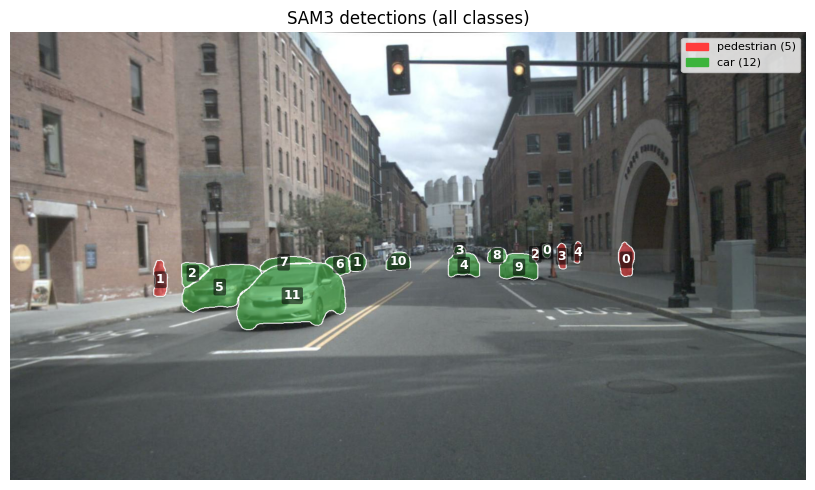

In [83]:
# ── SAM3 mask overlay ────────────────────────────────────────────────────────
CLASS_COLORS = {
    'pedestrian':           np.array([255,  60,  60], dtype=np.float32),
    'car':                  np.array([ 60, 180,  60], dtype=np.float32),
    'bicycle':              np.array([ 60, 120, 255], dtype=np.float32),
    'motorcycle':           np.array([255, 160,   0], dtype=np.float32),
    'bus':                  np.array([180,  60, 255], dtype=np.float32),
    'truck':                np.array([  0, 210, 210], dtype=np.float32),
    'construction vehicle': np.array([255,  80, 180], dtype=np.float32),
    'trailer':              np.array([140, 200,  60], dtype=np.float32),
}
_KERN = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

overlay     = img_rgb.copy().astype(np.float32)
outline_lyr = np.zeros((H, W), dtype=bool)

for prompt, dets in sam3_results.items():
    col = CLASS_COLORS.get(prompt, np.array([200, 200, 200], dtype=np.float32))
    for d in dets:
        overlay[d['binary_mask']] = overlay[d['binary_mask']] * 0.45 + col * 0.55
    for d in dets:
        mu8     = d['binary_mask'].astype(np.uint8) * 255
        outline_lyr |= (cv2.dilate(mu8, _KERN) > 0) & ~d['binary_mask']

overlay[outline_lyr] = 255.0

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[p] / 255, label=f'{p} ({len(dets)})')
    for p, dets in sam3_results.items() if dets
]
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(overlay.astype(np.uint8))
ax.axis('off')
ax.set_title('SAM3 detections (all classes)')
if legend_patches:
    ax.legend(handles=legend_patches, loc='upper right', fontsize=8)
# Draw per-class mask index at each mask centroid
for prompt, dets in sam3_results.items():
    for i, d in enumerate(dets):
        ys, xs = np.where(d['binary_mask'])
        if len(xs) == 0:
            continue
        cx_m, cy_m = float(xs.mean()), float(ys.mean())
        ax.text(cx_m, cy_m, str(i), color='white', fontsize=9, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.55, ec='none'))
plt.tight_layout()
plt.show()

## 4. LiDAR Loading + Camera Projection

Loads the LIDAR_TOP sweep whose timestamp is closest to the camera frame.
Projects all points into the camera image plane and keeps only those that
fall within the image bounds.

LiDAR aggregation: 3 unique sweep(s)
  [-1]  24,130 pts  dt=  -63.4 ms  n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151606798994.pcd.bin
  [+0]  24,133 pts  dt=  -13.6 ms  n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151606848763.pcd.bin  ← anchor
  [+1]  24,187 pts  dt=  +36.7 ms  n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151606899106.pcd.bin
  Total: 72,450 pts
Ego-body filter: applied per-sweep (ON)
Max range filter (52.0 m): removed 507 pts → 71,943 remaining

Visible in CAM_FRONT: 8,298 pts  [aggregated (1+1+1 sweeps)]


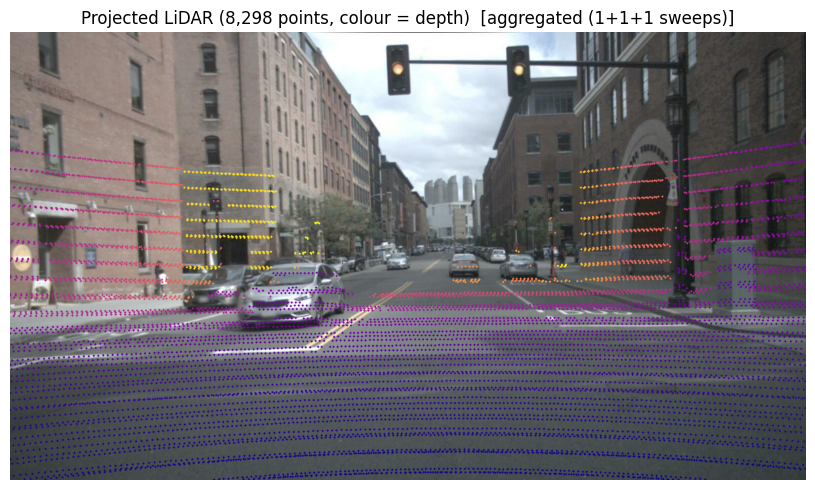

In [84]:
# ── Helper: walk LiDAR linked list, skip ECP duplicate file entries ───────────
def _walk_lidar_tokens(nusc, anchor_token, n_before, n_after):
    anchor_path = nusc.get_sample_data_path(anchor_token)
    seen_paths  = {anchor_path}

    backward = []
    tok = nusc.get('sample_data', anchor_token)['prev']
    while tok and len(backward) < n_before:
        path = nusc.get_sample_data_path(tok)
        if path not in seen_paths:
            backward.append(tok)
            seen_paths.add(path)
        tok = nusc.get('sample_data', tok)['prev']

    tokens = []
    for i, t in enumerate(reversed(backward)):
        tokens.append((-(len(backward) - i), t))
    tokens.append((0, anchor_token))

    count = 0
    tok   = nusc.get('sample_data', anchor_token)['next']
    while tok and count < n_after:
        path = nusc.get_sample_data_path(tok)
        if path not in seen_paths:
            count += 1
            tokens.append((count, tok))
            seen_paths.add(path)
        tok = nusc.get('sample_data', tok)['next']

    return tokens   # (rel_idx, token), chronological


def _load_sweep(nusc, tok, R_e2g_anchor, t_e2g_anchor):
    """Load one sweep, transform to anchor ego frame, return (N, 3) float64."""
    sd       = nusc.get('sample_data', tok)
    lid_cal  = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    ego_pose = nusc.get('ego_pose', sd['ego_pose_token'])
    lid_path = nusc.get_sample_data_path(tok)

    R_l2e    = Quaternion(lid_cal['rotation']).rotation_matrix.astype(np.float64)
    t_l2e    = np.array(lid_cal['translation'], dtype=np.float64)
    R_e2g_sw = Quaternion(ego_pose['rotation']).rotation_matrix.astype(np.float64)
    t_e2g_sw = np.array(ego_pose['translation'], dtype=np.float64)

    pts_raw = np.fromfile(lid_path, dtype=np.float32).reshape(-1, 5)[:, :3].astype(np.float64)

    pts_ego_sw  = (R_l2e @ pts_raw.T).T + t_l2e
    # ── Ego-body filter in sweep's own ego frame (vehicle always at origin) ──
    if USE_EGO_BODY_FILTER:
        _sw_box = (
            (np.abs(pts_ego_sw[:, 0]) < EGO_BOX_HALF_X) &
            (np.abs(pts_ego_sw[:, 1]) < EGO_BOX_HALF_Y) &
            (pts_ego_sw[:, 2] > EGO_BOX_Z_MIN) &
            (pts_ego_sw[:, 2] < EGO_BOX_Z_MAX)
        )
        pts_ego_sw = pts_ego_sw[~_sw_box]
    pts_global  = (R_e2g_sw @ pts_ego_sw.T).T + t_e2g_sw
    pts_ego_anc = (R_e2g_anchor.T @ (pts_global - t_e2g_anchor).T).T
    return pts_ego_anc, Path(lid_path).name


# ── Find anchor LiDAR sweep ───────────────────────────────────────────────────
cam_ts = cam_sd['timestamp']

if cam_sd['is_key_frame']:
    _sample     = nusc.get('sample', cam_sd['sample_token'])
    lidar_token = _sample['data']['LIDAR_TOP']
else:
    lidar_token = min(
        (sd for sd in nusc.sample_data if sd['channel'] == 'LIDAR_TOP'),
        key=lambda sd: abs(sd['timestamp'] - cam_ts),
    )['token']

# ── Load: single sweep or aggregated ─────────────────────────────────────────
if not USE_AGGREGATION:
    pts_ego, fname = _load_sweep(nusc, lidar_token, R_e2g_anchor, t_e2g_anchor)
    lidar_sd = nusc.get('sample_data', lidar_token)
    dt_ms    = abs(cam_ts - lidar_sd['timestamp']) / 1_000.0
    print(f'LiDAR (single sweep): {len(pts_ego):,} pts  dt={dt_ms:.1f} ms  ({fname})')
else:
    sweep_tokens = _walk_lidar_tokens(nusc, lidar_token, N_BEFORE, N_AFTER)
    all_pts = []
    print(f'LiDAR aggregation: {len(sweep_tokens)} unique sweep(s)')
    for rel_idx, tok in sweep_tokens:
        sweep_pts, fname = _load_sweep(nusc, tok, R_e2g_anchor, t_e2g_anchor)
        sd_info = nusc.get('sample_data', tok)
        dt_ms   = (sd_info['timestamp'] - cam_ts) / 1_000.0
        all_pts.append(sweep_pts)
        tag = '  ← anchor' if rel_idx == 0 else ''
        print(f'  [{rel_idx:+d}]  {len(sweep_pts):6,} pts  dt={dt_ms:+7.1f} ms  {fname}{tag}')
    pts_ego = np.concatenate(all_pts, axis=0)
    print(f'  Total: {len(pts_ego):,} pts')

# Ego-body filter applied per-sweep above (in each sweep's own ego frame).
print(f'Ego-body filter: applied per-sweep ({"ON" if USE_EGO_BODY_FILTER else "OFF"})')

# ── Max range filter ──────────────────────────────────────────────────────────
_bev_range      = np.sqrt(pts_ego[:, 0]**2 + pts_ego[:, 1]**2)
_n_before_range = len(pts_ego)
pts_ego         = pts_ego[_bev_range <= MAX_LIDAR_RANGE_M]
print(f'Max range filter ({MAX_LIDAR_RANGE_M} m): removed {_n_before_range - len(pts_ego):,} pts '
      f'→ {len(pts_ego):,} remaining')

# ── Project LiDAR → camera frame ─────────────────────────────────────────────
pts_cam  = (R_c2e.T @ (pts_ego - t_c2e).T).T
Z_cam    = pts_cam[:, 2]
in_front = Z_cam > 0.1

u_all = pts_cam[in_front, 0] / pts_cam[in_front, 2] * fx + cx
v_all = pts_cam[in_front, 1] / pts_cam[in_front, 2] * fy + cy

u_int_all = np.round(u_all).astype(int)
v_int_all = np.round(v_all).astype(int)
in_img    = (u_int_all >= 0) & (u_int_all < W) & (v_int_all >= 0) & (v_int_all < H)

idx_front = np.where(in_front)[0]
idx_vis   = idx_front[in_img]

u_vis       = u_all[in_img]
v_vis       = v_all[in_img]
Z_vis       = Z_cam[in_front][in_img]
pts_ego_vis = pts_ego[idx_vis]
pts_cam_vis = pts_cam[idx_vis]

mode_str = (f'aggregated ({N_BEFORE}+1+{N_AFTER} sweeps)'
            if USE_AGGREGATION else 'single sweep')
print(f'\nVisible in {CAMERA}: {len(u_vis):,} pts  [{mode_str}]')

# ── Depth overlay on image ────────────────────────────────────────────────────
vis_depth  = img_rgb.copy()
_z_norm    = np.clip((Z_vis - Z_vis.min()) / (Z_vis.max() - Z_vis.min() + 1e-8), 0, 1)
_cmap      = plt.get_cmap('plasma')
for i in range(len(u_vis)):
    col = tuple(int(c * 255) for c in _cmap(_z_norm[i])[:3])
    cv2.circle(vis_depth, (int(u_vis[i]), int(v_vis[i])), 2, col, -1)

plt.figure(figsize=(14, 5))
plt.imshow(vis_depth)
plt.axis('off')
plt.title(f'Projected LiDAR ({len(u_vis):,} points, colour = depth)  [{mode_str}]')
plt.tight_layout()
plt.show()

## 5. Mask Selection + In-Mask LiDAR Points

Set `MASK_PROMPT` and `MASK_IDX` in **Section 1** to pick a different object,
then re-run from here — no need to reload LiDAR or re-run SAM3.

Selected: prompt="car", idx=4, score=0.895, pixels=2,359
In-mask LiDAR points: 6 / 8298 visible


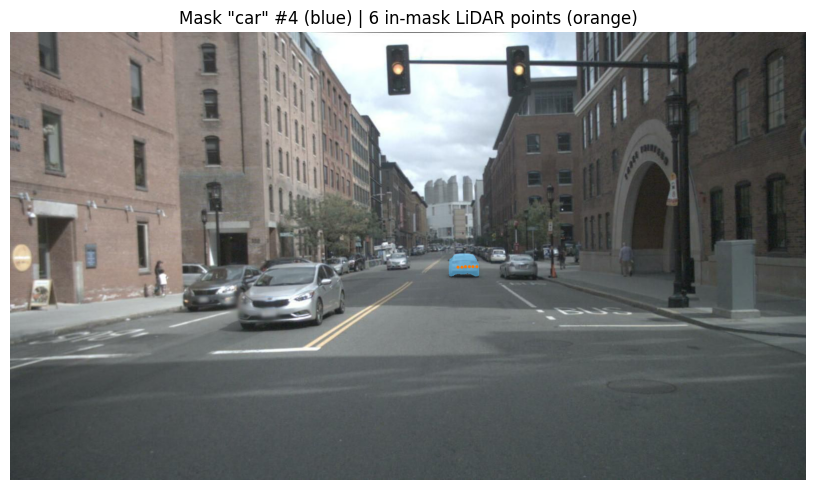

In [85]:
# ── Select the target SAM3 mask ───────────────────────────────────────────────
_dets = sam3_results.get(MASK_PROMPT, [])
assert _dets, f'No SAM3 detections for prompt "{MASK_PROMPT}" — check MASK_PROMPT'
assert MASK_IDX < len(_dets), (
    f'MASK_IDX={MASK_IDX} out of range — only {len(_dets)} detection(s) for "{MASK_PROMPT}"'
)

target_mask  = _dets[MASK_IDX]['binary_mask']   # (H, W) bool
target_score = _dets[MASK_IDX]['score']
print(f'Selected: prompt="{MASK_PROMPT}", idx={MASK_IDX}, '
      f'score={target_score:.3f}, pixels={target_mask.sum():,}')

# ── Keep only visible LiDAR points that project inside this mask ──────────────
u_int_vis = np.round(u_vis).astype(int)
v_int_vis = np.round(v_vis).astype(int)
in_mask   = target_mask[v_int_vis, u_int_vis]

pts_ego_inmask = pts_ego_vis[in_mask]
pts_cam_inmask = pts_cam_vis[in_mask]
u_inmask       = u_vis[in_mask]
v_inmask       = v_vis[in_mask]
Z_inmask       = Z_vis[in_mask]

print(f'In-mask LiDAR points: {in_mask.sum()} / {len(u_vis)} visible')

# ── Show mask + in-mask LiDAR points overlaid on image ───────────────────────
vis_mask = img_rgb.copy().astype(np.float32)
vis_mask[target_mask] = vis_mask[target_mask] * 0.4 + np.array([100, 200, 255]) * 0.6

for i in range(len(u_inmask)):
    cv2.circle(vis_mask, (int(u_inmask[i]), int(v_inmask[i])), 3, (255, 120, 0), -1)

plt.figure(figsize=(14, 5))
plt.imshow(vis_mask.astype(np.uint8))
plt.axis('off')
plt.title(f'Mask "{MASK_PROMPT}" #{MASK_IDX} (blue) | {in_mask.sum()} in-mask LiDAR points (orange)')
plt.tight_layout()
plt.show()

## 5b. 3D Point Cloud — All LiDAR vs. In-Mask Points

All ego-frame LiDAR points in **gray**; points that project inside the selected mask in **red**.

In [86]:
# ── Downsample background for a responsive plot ───────────────────────────────
_rng3d    = np.random.default_rng(0)
_n_bg3d   = min(40_000, len(pts_ego))
_idx_bg3d = _rng3d.choice(len(pts_ego), _n_bg3d, replace=False)
_bg3d     = pts_ego[_idx_bg3d]

fig_3d = go.Figure()

# ── All LiDAR — gray ──────────────────────────────────────────────────────────
fig_3d.add_trace(go.Scatter3d(
    x=_bg3d[:, 0], y=_bg3d[:, 1], z=_bg3d[:, 2],
    mode='markers',
    marker=dict(size=1, color='rgba(160,170,185,0.25)'),
    name=f'all LiDAR ({len(pts_ego):,} pts, {_n_bg3d:,} shown)',
    hoverinfo='skip',
))

# ── In-mask LiDAR — red ───────────────────────────────────────────────────────
fig_3d.add_trace(go.Scatter3d(
    x=pts_ego_inmask[:, 0], y=pts_ego_inmask[:, 1], z=pts_ego_inmask[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        color='rgba(255,60,60,0.9)',
        line=dict(width=0),
    ),
    name=f'in-mask "{MASK_PROMPT}" #{MASK_IDX} ({len(pts_ego_inmask)} pts)',
))

# ── Ego vehicle marker ────────────────────────────────────────────────────────
fig_3d.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=6, color='yellow', symbol='diamond',
                line=dict(color='black', width=1)),
    name='ego',
))

fig_3d.update_layout(
    title=f'3D LiDAR — all (gray) vs. in-mask "{MASK_PROMPT}" #{MASK_IDX} (red)',
    scene=dict(
        xaxis=dict(title='X ego (forward, m)', backgroundcolor='rgb(10,10,20)',
                   gridcolor='rgba(255,255,255,0.06)', showbackground=True),
        yaxis=dict(title='Y ego (left, m)',    backgroundcolor='rgb(10,10,20)',
                   gridcolor='rgba(255,255,255,0.06)', showbackground=True),
        zaxis=dict(title='Z ego (up, m)',      backgroundcolor='rgb(10,10,20)',
                   gridcolor='rgba(255,255,255,0.06)', showbackground=True),
        bgcolor='rgb(10,10,20)',
        aspectmode='data',
        camera=dict(eye=dict(x=0.5, y=-1.8, z=1.2)),
    ),
    paper_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.55)', font=dict(size=11)),
    width=1000, height=650,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig_3d.show()


## 6. HDBSCAN Clustering

HDBSCAN is applied to the **3-D ego-frame coordinates** of the in-mask points.
Operating in metric space means the distance threshold is physically meaningful
and the same `min_cluster_size` works at all ranges — unlike image-plane DBSCAN
which would need an `eps` that grows with distance.

In [87]:
# ── Resolve per-class HDBSCAN parameters ─────────────────────────────────────
_hp = HDBSCAN_PARAMS[MASK_PROMPT]
HDBSCAN_MIN_CLUSTER_SIZE = _hp['min_cluster_size']
HDBSCAN_MIN_SAMPLES      = _hp['min_samples']
HDBSCAN_CLUSTER_EPS      = _hp['cluster_eps']

print(f'HDBSCAN params for "{MASK_PROMPT}": '
      f'min_cluster_size={HDBSCAN_MIN_CLUSTER_SIZE}  '
      f'min_samples={HDBSCAN_MIN_SAMPLES}  '
      f'cluster_eps={HDBSCAN_CLUSTER_EPS}m')

# ── HDBSCAN on 3-D ego-frame coordinates ─────────────────────────────────────
if len(pts_ego_inmask) < HDBSCAN_MIN_CLUSTER_SIZE:
    print(f'[WARN] Too few in-mask points ({len(pts_ego_inmask)}) — skipping.')
    labels_raw = labels = np.full(len(pts_ego_inmask), -1, dtype=int)
    n_clusters_raw = n_clusters = 0
else:
    # ── Pass 1: without epsilon → raw subclusters ─────────────────────────────
    _c_raw = hdbscan.HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric='euclidean',
    )
    labels_raw     = _c_raw.fit_predict(pts_ego_inmask)
    n_clusters_raw = int(labels_raw.max()) + 1

    # ── Pass 2: with epsilon → merged clusters ────────────────────────────────
    _c_merged = hdbscan.HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric='euclidean',
        cluster_selection_epsilon=HDBSCAN_CLUSTER_EPS,
    )
    labels     = _c_merged.fit_predict(pts_ego_inmask)
    n_clusters = int(labels.max()) + 1

# ── Print summary ─────────────────────────────────────────────────────────────
print(f'Without ε : {n_clusters_raw} cluster(s), {(labels_raw == -1).sum()} noise pts')
print(f'With ε={HDBSCAN_CLUSTER_EPS}m : {n_clusters} cluster(s), {(labels == -1).sum()} noise pts')

if n_clusters > 0:
    print()
    n_merged_total = 0
    for c in range(n_clusters):
        final_mask  = labels == c
        raw_in_final = sorted(set(labels_raw[final_mask].tolist()) - {-1})
        n_raw        = len(raw_in_final)
        n_merged_total += max(0, n_raw - 1)

        pts = pts_ego_inmask[final_mask]
        span = pts.max(axis=0) - pts.min(axis=0)
        merge_str = (f'merged {n_raw} raw subclusters {raw_in_final}'
                     if n_raw > 1 else f'1 raw subcluster (no merge)')
        print(f'  Cluster {c}: {final_mask.sum()} pts  '
              f'span=[{span[0]:.2f}m, {span[1]:.2f}m, {span[2]:.2f}m]  '
              f'← {merge_str}')

    if n_merged_total > 0:
        print(f'\n  → ε={HDBSCAN_CLUSTER_EPS}m merged away {n_merged_total} split(s)')

# ── Cluster selection (top-2 proximity) ──────────────────────────────────────
# If the biggest cluster has >= PROXIMITY_MIN_PTS points AND the second biggest
# has >= PROXIMITY_RATIO * biggest count, both are candidates and we prefer the
# one closer to the ego origin — this rejects background walls that accumulate
# a similar number of in-mask returns as the foreground object.
# Otherwise fall back to the largest cluster (original behaviour).
PROXIMITY_MIN_PTS = 30
PROXIMITY_RATIO   = 0.70

if n_clusters > 0:
    _cluster_counts = np.array([(labels == c).sum() for c in range(n_clusters)])
    _order          = np.argsort(_cluster_counts)[::-1]  # descending by count
    _biggest        = int(_cluster_counts[_order[0]])

    if (_biggest >= PROXIMITY_MIN_PTS
            and len(_order) >= 2
            and _cluster_counts[_order[1]] >= PROXIMITY_RATIO * _biggest):
        _c0, _c1 = int(_order[0]), int(_order[1])
        _d0 = float(np.linalg.norm(pts_ego_inmask[labels == _c0].mean(axis=0)))
        _d1 = float(np.linalg.norm(pts_ego_inmask[labels == _c1].mean(axis=0)))
        _dominant_idx   = _c0 if _d0 <= _d1 else _c1
        _selection_mode = (f'proximity — top-2: #{_c0} {_cluster_counts[_c0]}pts@{_d0:.1f}m '
                           f'vs #{_c1} {_cluster_counts[_c1]}pts@{_d1:.1f}m')
    else:
        _dominant_idx   = int(_order[0])
        _selection_mode = 'biggest'

    print(f'\nCluster selection ({_selection_mode}):')
    for c in range(n_clusters):
        tag = '  ← SELECTED' if c == _dominant_idx else ''
        print(f'  Cluster {c}: {_cluster_counts[c]} pts{tag}')

HDBSCAN params for "car": min_cluster_size=2  min_samples=1  cluster_eps=0.5m
Without ε : 2 cluster(s), 2 noise pts
With ε=0.5m : 2 cluster(s), 2 noise pts

  Cluster 0: 2 pts  span=[0.02m, 0.22m, 0.00m]  ← 1 raw subcluster (no merge)
  Cluster 1: 2 pts  span=[0.04m, 0.23m, 0.00m]  ← 1 raw subcluster (no merge)

Cluster selection (biggest):
  Cluster 0: 2 pts
  Cluster 1: 2 pts  ← SELECTED


## 7. BEV Visualization

Full LiDAR sweep in gray; in-mask points colored by HDBSCAN cluster label.
Noise points (label −1) are shown as red crosses.

In [88]:
CLUSTER_PALETTE = [
    'rgb(255,80,80)',   'rgb(80,220,80)',   'rgb(80,120,255)',  'rgb(255,200,0)',
    'rgb(200,80,255)',  'rgb(0,210,210)',   'rgb(255,100,0)',   'rgb(60,255,200)',
    'rgb(255,60,180)',  'rgb(160,220,60)',
]
# Different symbols for raw subclusters within the same merged cluster
RAW_SYMBOLS = ['circle', 'square', 'diamond', 'triangle-up', 'triangle-down',
               'star', 'hexagram', 'cross', 'pentagon', 'bowtie']

NOISE_COLOR = 'rgb(220,80,80)'
LIDAR_COLOR = 'rgba(100,130,160,0.35)'

# Downsample background LiDAR
_rng   = np.random.default_rng(42)
_n_bg  = min(30_000, len(pts_ego))
_idx_b = _rng.choice(len(pts_ego), _n_bg, replace=False)
_pts_b = pts_ego[_idx_b]
_bev_m = (np.abs(_pts_b[:, 0]) < 70) & (np.abs(_pts_b[:, 1]) < 35)
_pts_b = _pts_b[_bev_m]

bev_traces = []

# ── Background LiDAR ──────────────────────────────────────────────────────────
bev_traces.append(go.Scatter(
    x=_pts_b[:, 0], y=_pts_b[:, 1],
    mode='markers',
    marker=dict(size=1, color=LIDAR_COLOR),
    name='LiDAR (all)', hoverinfo='skip',
))

# ── Noise points ──────────────────────────────────────────────────────────────
_noise = labels == -1
if _noise.any():
    bev_traces.append(go.Scatter(
        x=pts_ego_inmask[_noise, 0], y=pts_ego_inmask[_noise, 1],
        mode='markers',
        marker=dict(size=7, color=NOISE_COLOR, symbol='x'),
        name=f'noise (−1)  [{_noise.sum()} pts]',
    ))

# ── Cluster points: one trace per raw subcluster, colored by merged parent ────
for c in range(n_clusters):
    final_mask   = labels == c
    col          = CLUSTER_PALETTE[c % len(CLUSTER_PALETTE)]
    raw_in_final = sorted(set(labels_raw[final_mask].tolist()) - {-1})
    n_raw        = len(raw_in_final)

    for sym_i, raw_c in enumerate(raw_in_final):
        raw_mask = final_mask & (labels_raw == raw_c)
        symbol   = RAW_SYMBOLS[sym_i % len(RAW_SYMBOLS)]
        is_first = sym_i == 0

        if n_raw > 1:
            legend_label = (f'cluster {c} — raw {raw_c}/{raw_in_final[-1]}'
                            f'  [{raw_mask.sum()} pts]')
        else:
            legend_label = f'cluster {c}  [{raw_mask.sum()} pts]'

        bev_traces.append(go.Scatter(
            x=pts_ego_inmask[raw_mask, 0], y=pts_ego_inmask[raw_mask, 1],
            mode='markers',
            marker=dict(
                size=10 if n_raw == 1 else 9,
                color=col,
                symbol=symbol,
                line=dict(width=1 if is_first else 0, color='white'),
            ),
            name=legend_label,
            legendgroup=f'cluster_{c}',
        ))

    # If merges happened: draw a dashed convex-hull outline around the full cluster
    if n_raw > 1:
        _pts_c = pts_ego_inmask[final_mask]
        try:
            from scipy.spatial import ConvexHull
            hull = ConvexHull(_pts_c[:, :2])
            hx   = np.append(_pts_c[hull.vertices, 0], _pts_c[hull.vertices[0], 0])
            hy   = np.append(_pts_c[hull.vertices, 1], _pts_c[hull.vertices[0], 1])
            bev_traces.append(go.Scatter(
                x=hx, y=hy, mode='lines',
                line=dict(color=col, width=1.5, dash='dot'),
                showlegend=False, hoverinfo='skip',
            ))
        except Exception:
            pass  # ConvexHull needs ≥3 non-collinear points

# ── Ego vehicle marker ────────────────────────────────────────────────────────
bev_traces.append(go.Scatter(
    x=[0], y=[0], mode='markers',
    marker=dict(symbol='arrow-up', angle=90, size=16,
                color='yellow', line=dict(color='black', width=1)),
    name='ego', showlegend=True,
))

merge_note = (f'{n_clusters_raw}→{n_clusters} after ε={HDBSCAN_CLUSTER_EPS}m'
              if n_clusters_raw != n_clusters else f'no merges (ε={HDBSCAN_CLUSTER_EPS}m)')

fig_bev = go.Figure(data=bev_traces)
fig_bev.update_layout(
    title=(
        f'BEV — "{MASK_PROMPT}" #{MASK_IDX} | HDBSCAN '
        f'(min_cluster_size={HDBSCAN_MIN_CLUSTER_SIZE}, '
        f'min_samples={HDBSCAN_MIN_SAMPLES}) | {merge_note}'
    ),
    xaxis=dict(
        title='X ego (forward, m)', range=[-10, 70],
        scaleanchor='y', scaleratio=1,
        showgrid=True, gridcolor='rgba(255,255,255,0.08)', zeroline=False,
    ),
    yaxis=dict(
        title='Y ego (left, m)', range=[-35, 35],
        showgrid=True, gridcolor='rgba(255,255,255,0.08)', zeroline=False,
    ),
    plot_bgcolor='rgb(15,15,25)',
    paper_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(0,0,0,0.55)', font=dict(size=11)),
    width=1000, height=580,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig_bev.show()

## 8. Image Overlay

Project the in-mask LiDAR points back onto the image, colored by their HDBSCAN cluster label.

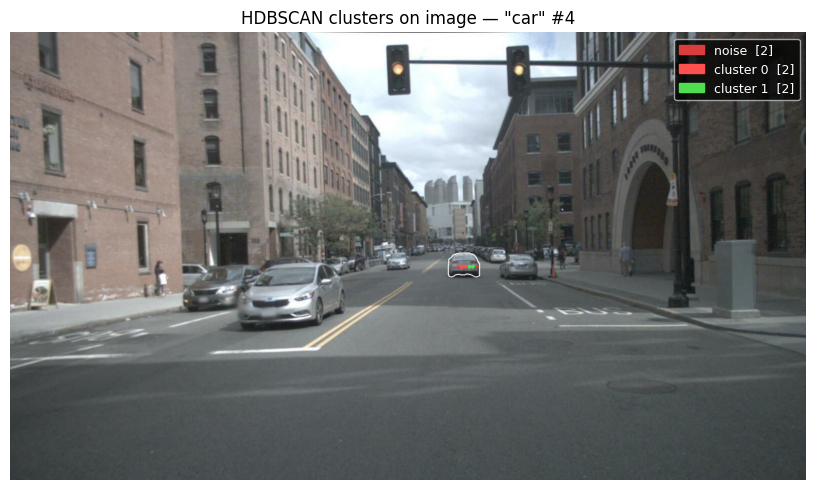

In [89]:
import re as _re


def _parse_rgb(s):
    """'rgb(r,g,b)' → (r, g, b) int tuple."""
    vals = _re.findall(r'\d+', s)
    return tuple(int(v) for v in vals[:3])


vis_img = img_rgb.copy()

# Draw mask outline in white
_mu8     = target_mask.astype(np.uint8) * 255
_kern5   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
_outline = (cv2.dilate(_mu8, _kern5) > 0) & ~target_mask
vis_img[_outline] = [255, 255, 255]

# Noise points — red dots
_noise = labels == -1
for i in np.where(_noise)[0]:
    cv2.circle(vis_img, (int(u_inmask[i]), int(v_inmask[i])), 3, (220, 60, 60), -1)

# Cluster points — colored by cluster
for c in range(n_clusters):
    _col = _parse_rgb(CLUSTER_PALETTE[c % len(CLUSTER_PALETTE)])
    for i in np.where(labels == c)[0]:
        cv2.circle(vis_img, (int(u_inmask[i]), int(v_inmask[i])), 4, _col, -1)

# Build legend
_legend = []
if _noise.any():
    _legend.append(mpatches.Patch(
        color=np.array([220, 60, 60]) / 255, label=f'noise  [{_noise.sum()}]'
    ))
for c in range(n_clusters):
    _col_rgb = np.array(_parse_rgb(CLUSTER_PALETTE[c % len(CLUSTER_PALETTE)])) / 255.0
    _legend.append(mpatches.Patch(
        color=_col_rgb, label=f'cluster {c}  [{(labels == c).sum()}]'
    ))

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(vis_img)
ax.axis('off')
ax.set_title(f'HDBSCAN clusters on image — "{MASK_PROMPT}" #{MASK_IDX}')
if _legend:
    ax.legend(handles=_legend, loc='upper right', fontsize=9,
              facecolor='black', labelcolor='white', framealpha=0.75)
plt.tight_layout()
plt.show()

## 9. Mask Erosion

Morphological erosion of the SAM3 mask by a fixed number of pixels **before** HDBSCAN point selection.

- Removes boundary pixels where mask inaccuracy lets nearby occluders (signs, poles) bleed in
- Applied equally to **all connected components** — small blobs (occluder fragments) may disappear entirely
- Erosion is skipped when the mask is already small (< `MASK_ERODE_MIN_PX`)
- The convex hull for depth clamping still uses the **full** original mask

**Blue** = kept mask area | **Red** = eroded boundary strip

Erosion 3px: 2,359 -> 1,816 px (removed 543 boundary px)
In-mask LiDAR: 6 -> 6 pts after erosion


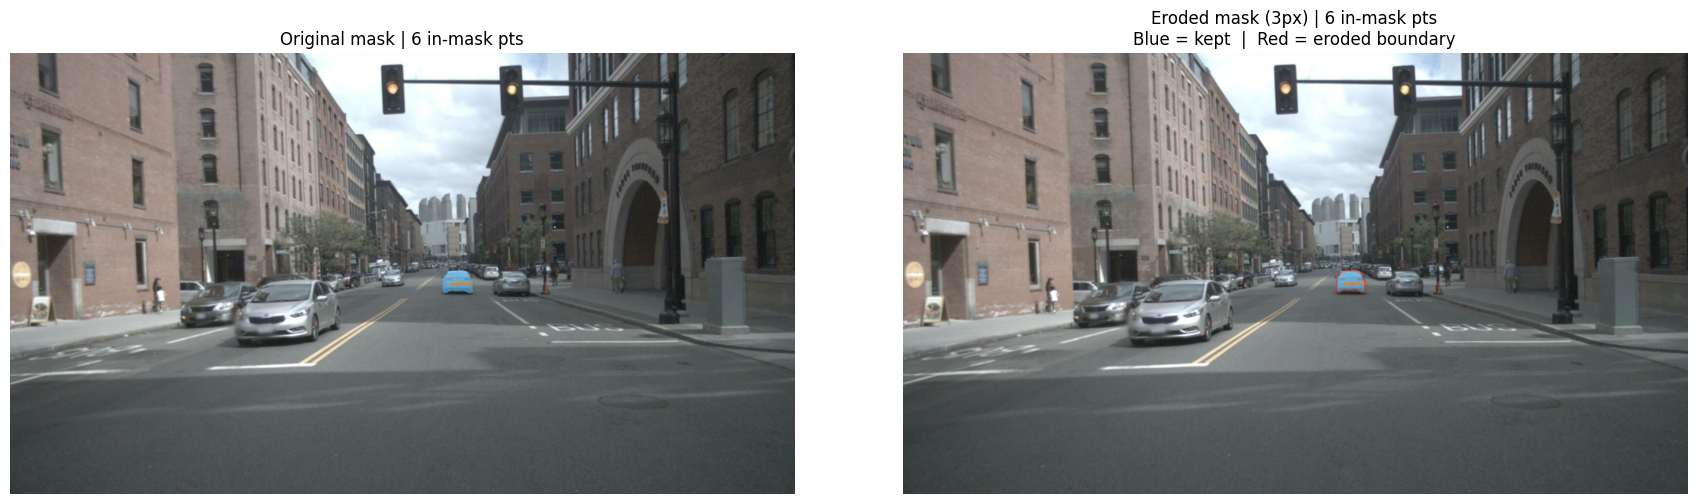

In [90]:
MASK_ERODE_PX     = 3    # pixels to erode (applied to all connected components)
MASK_ERODE_MIN_PX = 500  # skip if mask area is already small

# -- Apply morphological erosion -----------------------------------------------
_mask_area = int(target_mask.sum())
if MASK_ERODE_PX > 0 and _mask_area >= MASK_ERODE_MIN_PX:
    _er_kernel  = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2 * MASK_ERODE_PX + 1, 2 * MASK_ERODE_PX + 1))
    eroded_mask = cv2.erode(target_mask.astype(np.uint8), _er_kernel).astype(bool)
    print(f'Erosion {MASK_ERODE_PX}px: {_mask_area:,} -> {eroded_mask.sum():,} px '
          f'(removed {_mask_area - int(eroded_mask.sum()):,} boundary px)')
else:
    eroded_mask = target_mask.copy()
    print(f'Erosion skipped -- mask area {_mask_area:,} px '
          f'(threshold: {MASK_ERODE_MIN_PX:,} px)')

# -- In-mask LiDAR with eroded mask -------------------------------------------
in_mask_eroded    = eroded_mask[v_int_vis, u_int_vis]
pts_ego_inmask_er = pts_ego_vis[in_mask_eroded]
u_inmask_er       = u_vis[in_mask_eroded]
v_inmask_er       = v_vis[in_mask_eroded]
Z_inmask_er       = Z_vis[in_mask_eroded]
print(f'In-mask LiDAR: {in_mask.sum()} -> {int(in_mask_eroded.sum())} pts after erosion')

# -- Visualise original vs eroded mask -----------------------------------------
_removed_boundary = target_mask & ~eroded_mask

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: original mask
_v0 = img_rgb.copy().astype(np.float32)
_v0[target_mask] = _v0[target_mask] * 0.4 + np.array([100, 200, 255]) * 0.6
for _i in range(len(u_inmask)):
    cv2.circle(_v0, (int(u_inmask[_i]), int(v_inmask[_i])), 3, (255, 120, 0), -1)
axes[0].imshow(_v0.astype(np.uint8))
axes[0].set_title(f'Original mask | {in_mask.sum()} in-mask pts')
axes[0].axis('off')

# Right: eroded mask -- kept=blue, removed boundary=red
_v1 = img_rgb.copy().astype(np.float32)
_v1[eroded_mask]       = _v1[eroded_mask] * 0.4 + np.array([100, 200, 255]) * 0.6
_v1[_removed_boundary] = _v1[_removed_boundary] * 0.4 + np.array([255, 60, 60]) * 0.6
for _i in range(len(u_inmask_er)):
    cv2.circle(_v1, (int(u_inmask_er[_i]), int(v_inmask_er[_i])), 3, (255, 120, 0), -1)
axes[1].imshow(_v1.astype(np.uint8))
axes[1].set_title(f'Eroded mask ({MASK_ERODE_PX}px) | {int(in_mask_eroded.sum())} in-mask pts\n'
                  f'Blue = kept  |  Red = eroded boundary')
axes[1].axis('off')

plt.tight_layout()
plt.show()

HDBSCAN (eroded mask): 2 cluster(s), 2 noise pts
  Cluster 0: 2 pts
  Cluster 1: 2 pts  <- SELECTED
Selection: biggest: C1 (2 pts)


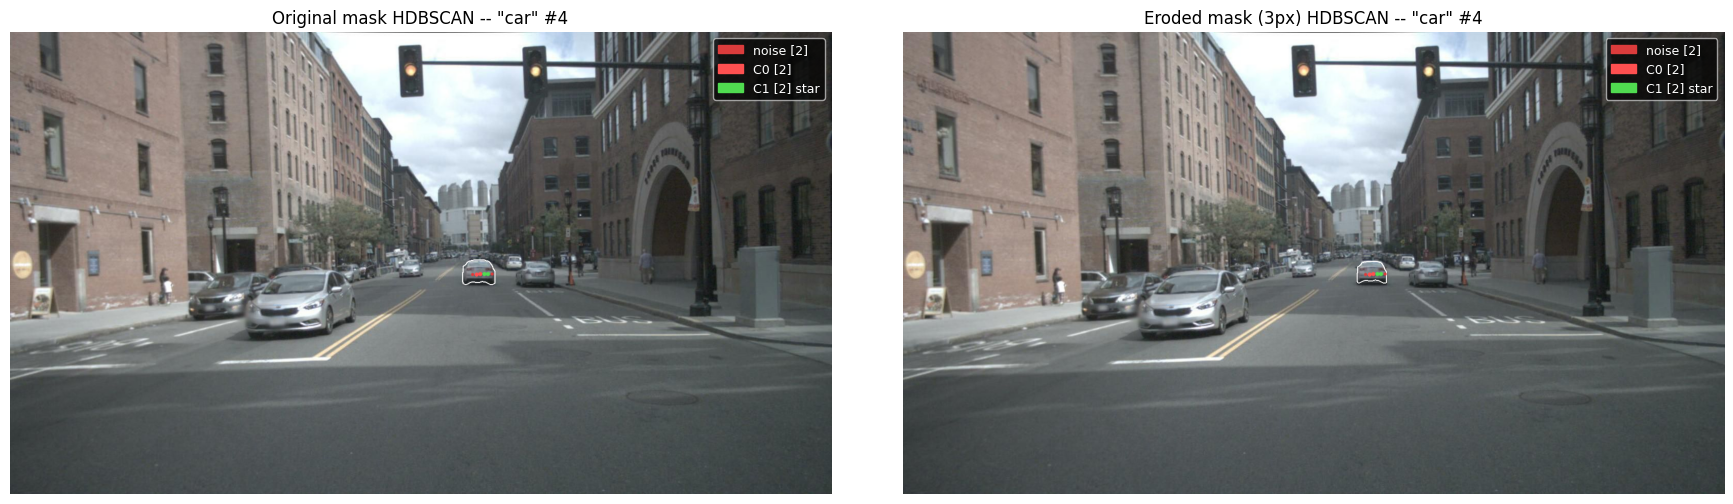

In [91]:
# -- HDBSCAN on eroded in-mask points -----------------------------------------
if len(pts_ego_inmask_er) < HDBSCAN_MIN_CLUSTER_SIZE:
    print(f'[WARN] Too few in-mask points after erosion ({len(pts_ego_inmask_er)}) -- skipping.')
    labels_er     = np.full(len(pts_ego_inmask_er), -1, dtype=int)
    n_clusters_er = 0
else:
    _c_er = hdbscan.HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric='euclidean',
        cluster_selection_epsilon=HDBSCAN_CLUSTER_EPS,
    )
    labels_er     = _c_er.fit_predict(pts_ego_inmask_er)
    n_clusters_er = int(labels_er.max()) + 1

print(f'HDBSCAN (eroded mask): {n_clusters_er} cluster(s), {(labels_er == -1).sum()} noise pts')

# -- Cluster selection (same proximity logic) ----------------------------------
_dom_er      = 0
_sel_mode_er = 'n/a'
if n_clusters_er > 0:
    _cc_er  = np.array([(labels_er == c).sum() for c in range(n_clusters_er)])
    _ord_er = np.argsort(_cc_er)[::-1]
    _big_er = int(_cc_er[_ord_er[0]])
    if (_big_er >= PROXIMITY_MIN_PTS
            and len(_ord_er) >= 2
            and _cc_er[_ord_er[1]] >= PROXIMITY_RATIO * _big_er):
        _c0e, _c1e = int(_ord_er[0]), int(_ord_er[1])
        _d0e = float(np.linalg.norm(pts_ego_inmask_er[labels_er == _c0e].mean(axis=0)))
        _d1e = float(np.linalg.norm(pts_ego_inmask_er[labels_er == _c1e].mean(axis=0)))
        _dom_er      = _c0e if _d0e <= _d1e else _c1e
        _sel_mode_er = (f'proximity: C{_c0e} {_cc_er[_c0e]}pts@{_d0e:.1f}m '
                        f'vs C{_c1e} {_cc_er[_c1e]}pts@{_d1e:.1f}m -> C{_dom_er}')
    else:
        _dom_er      = int(_ord_er[0])
        _sel_mode_er = f'biggest: C{_dom_er} ({_big_er} pts)'
    for c in range(n_clusters_er):
        tag = '  <- SELECTED' if c == _dom_er else ''
        print(f'  Cluster {c}: {_cc_er[c]} pts{tag}')
print(f'Selection: {_sel_mode_er}')

# -- Side-by-side: original vs eroded HDBSCAN clusters on image ---------------
_k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

def _draw_clusters(base_img, mask, u_arr, v_arr, lbl, dom_idx, n_cl):
    vis = base_img.copy()
    _outline = (cv2.dilate(mask.astype(np.uint8) * 255, _k5) > 0) & ~mask
    vis[_outline] = [255, 255, 255]
    for _i in np.where(lbl == -1)[0]:
        cv2.circle(vis, (int(u_arr[_i]), int(v_arr[_i])), 3, (220, 60, 60), -1)
    for _c in range(n_cl):
        _col = _parse_rgb(CLUSTER_PALETTE[_c % len(CLUSTER_PALETTE)])
        for _i in np.where(lbl == _c)[0]:
            cv2.circle(vis, (int(u_arr[_i]), int(v_arr[_i])), 4, _col, -1)
    _leg = []
    if (lbl == -1).any():
        _leg.append(mpatches.Patch(color=np.array([220, 60, 60]) / 255,
                                   label=f'noise [{(lbl == -1).sum()}]'))
    for _c in range(n_cl):
        _cr  = np.array(_parse_rgb(CLUSTER_PALETTE[_c % len(CLUSTER_PALETTE)])) / 255.0
        _stag = ' star' if _c == dom_idx else ''
        _leg.append(mpatches.Patch(color=_cr,
                                   label=f'C{_c} [{(lbl == _c).sum()}]{_stag}'))
    return vis, _leg

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

_vis_orig, _leg_orig = _draw_clusters(
    img_rgb, target_mask, u_inmask, v_inmask, labels, _dominant_idx, n_clusters)
axes[0].imshow(_vis_orig)
axes[0].axis('off')
axes[0].set_title(f'Original mask HDBSCAN -- "{MASK_PROMPT}" #{MASK_IDX}')
if _leg_orig:
    axes[0].legend(handles=_leg_orig, loc='upper right', fontsize=9,
                   facecolor='black', labelcolor='white', framealpha=0.75)

_vis_er, _leg_er = _draw_clusters(
    img_rgb, eroded_mask, u_inmask_er, v_inmask_er, labels_er, _dom_er, n_clusters_er)
axes[1].imshow(_vis_er)
axes[1].axis('off')
axes[1].set_title(f'Eroded mask ({MASK_ERODE_PX}px) HDBSCAN -- "{MASK_PROMPT}" #{MASK_IDX}')
if _leg_er:
    axes[1].legend(handles=_leg_er, loc='upper right', fontsize=9,
                   facecolor='black', labelcolor='white', framealpha=0.75)

plt.tight_layout()
plt.show()